**Modelo de Recuperación de Cartera**

1. Preparación de los datos

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Cargar dataset
df = pd.read_csv("prosperLoanData1.csv")


#Estados de la variable objetivo
status_map = {
    "Completed": 1,
    "FinalPaymentInProgress": 1,
    "Defaulted": 0,
    "Chargedoff": 0,
    "Past Due": None,
    "Current": None,
    "Cancelled": None
}

#definición de la variable objetivo
df["recuperado"] = df["LoanStatus"].map(status_map)
df_modelo = df.dropna(subset=["recuperado"])
##print (df_modelo["recuperado"].value_counts())

##Variables predictoras escogidas
features = ["BorrowerRate", "LoanOriginalAmount", "IncomeRange", "Term"]

##Matriz de características y variable objetivo
X = df_modelo[features]
y = df_modelo["recuperado"]

##división de los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split( 
    X, y, test_size=0.2, random_state=42, stratify=y #random_state=42 asegura que la división sea siempre igual (reproducible) y test size 20%
)

##Tipo de datos de las variables predictoras
num_features = ["BorrowerRate", "LoanOriginalAmount", "Term"]
cat_features = ["IncomeRange"]

##Escalado de las variables numéricas y codificación one-hot de las variables categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features), ##standardscaler media 0 y desviación estándar 1
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)




2. Modelo de Regresión Logística

In [26]:

##Se comienza definiendo el pipeline, que incluye el preprocesamiento que hicimos el paso anterior.
pipeline_log = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)), ##SMOTE es para balancear las clases (evita sesgo hacia la clase mayoritaria)
    ("model", LogisticRegression(max_iter=1000)) ##Aquí se define el modelo
])


##Parámetros a probar en la búsqueda de hiperparámetros 
param_grid_log = {"model__C": [0.01, 0.1, 1, 10]} 


##Búsqueda de hiperparámetros con validación cruzada (GridSearchCV) 
# para encontrar el mejor valor de C para la regresión logística. 

grid_log = GridSearchCV(
    pipeline_log,
    param_grid_log,
    cv=5, #cross-validation con 5 particiones
    scoring="roc_auc", #roc_auc es una métrica que evalúa la capacidad del modelo para distinguir entre clases
    n_jobs=-1 # Utilizar todos los núcleos disponibles en CPU
)

grid_log.fit(X_train, y_train)

#C = Regularizacion = Evitar que el modelo se ajuste demasiado a los datos de entrenamiento (overfitting). 
#Un valor más alto e C significa menos regularización, mientras que un valor más bajo significa más regularización.


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, w

3. Random Forest

In [27]:
#Pipeline para Random Forest
pipeline_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

#parámetros para el grid
param_grid_rf = {
    "model__n_estimators": [100, 200], # cuántos árboles usar
    "model__max_depth": [None, 10, 20],# profundidad máxima de cada árbol
    "model__min_samples_split": [2, 5] # mínimo de datos para dividir un nodo
}

grid_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose:

4. XGBOOST

In [28]:
##Pipeline para XGBoost
pipeline_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(eval_metric="logloss", random_state=42)) ##logloss es la función de pérdida logarítmica, que mide la diferencia entre las predicciones del modelo y los valores reales. Entre más bajo el logloss, better xd
])

#parámetros para el grid
param_grid_xgb = {
    "model__n_estimators": [100, 200], # número de árboles
    "model__max_depth": [3, 5, 7],     # profundidad de los árboles
    "model__learning_rate": [0.01, 0.1, 0.2] # velocidad de aprendizaje, desde mas lento y preciso (0.01) hasta mas rápido y menos preciso (0.2)
}

#hiperp
grid_xgb = GridSearchCV(
    pipeline_xgb,
    param_grid_xgb,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train) ##entrenar al modelo


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.1, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verb

3. Print Comparativo

In [29]:
print("=== Logistic Regression ===")
print(grid_log.best_params_) #mejores parámetros encontrados
print(classification_report(y_test, grid_log.predict(X_test))) #Metricas de evaluación del modelo en el conjunto de prueba
print("AUC:", roc_auc_score(y_test, grid_log.predict_proba(X_test)[:,1])) # puntaje AUC-ROC

print("\n=== Random Forest ===")
print(grid_rf.best_params_)
print(classification_report(y_test, grid_rf.predict(X_test)))
print("AUC:", roc_auc_score(y_test, grid_rf.predict_proba(X_test)[:,1]))

print("\n=== XGBoost ===")
print(grid_xgb.best_params_)
print(classification_report(y_test, grid_xgb.predict(X_test)))
print("AUC:", roc_auc_score(y_test, grid_xgb.predict_proba(X_test)[:,1]))

##Se utiliza TEST porque son los datos que el modelo no ha visto durante el entrenamiento,
#Esto permite evaluar la capacidad del modelo para generalizar a datos nuevos y no vistos,
#  lo que es crucial para determinar su rendimiento en situaciones del mundo real.


=== Logistic Regression ===
{'model__C': 1}
              precision    recall  f1-score   support

         0.0       0.43      0.65      0.52      3402
         1.0       0.80      0.61      0.69      7656

    accuracy                           0.62     11058
   macro avg       0.61      0.63      0.60     11058
weighted avg       0.68      0.62      0.64     11058

AUC: 0.6880435059713477

=== Random Forest ===
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}
              precision    recall  f1-score   support

         0.0       0.43      0.73      0.54      3402
         1.0       0.83      0.57      0.67      7656

    accuracy                           0.62     11058
   macro avg       0.63      0.65      0.61     11058
weighted avg       0.70      0.62      0.63     11058

AUC: 0.7080009561650685

=== XGBoost ===
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
              precision    recall  f1-score   sup

**Conclusiones de los modelos**

Para este análisis se seleccionó el modelo Random Forest como el más adecuado. Aunque la regresión logística mostró un desempeño más equilibrado entre ambas clases, Random Forest alcanzó un recall de 0.73 en la clase de préstamos no recuperados, lo que significa que logra identificar la mayoría de los incumplidos, aspecto crítico para la gestión del riesgo. Además, su AUC de 0.708 indica una mejor capacidad global para diferenciar entre préstamos recuperados y no recuperados en comparación con la regresión logística. En conclusión, Random Forest ofrece un balance razonable entre precisión y recall, y prioriza la detección de incumplidos, lo cual es más relevante para el negocio.

**Figuras Clave**

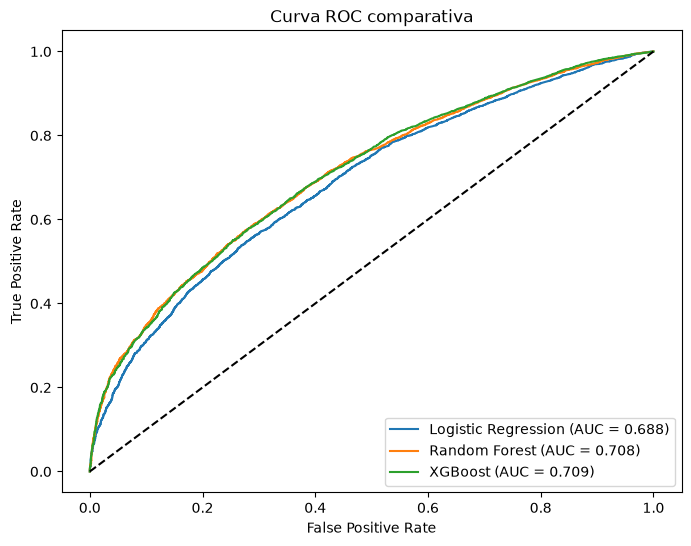

In [30]:
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc

# Modelos ya entrenados: grid_log, grid_rf, grid_xgb
models = {
    "Logistic Regression": grid_log,
    "Random Forest": grid_rf,
    "XGBoost": grid_xgb
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC comparativa")
plt.legend(loc="lower right")
plt.show()


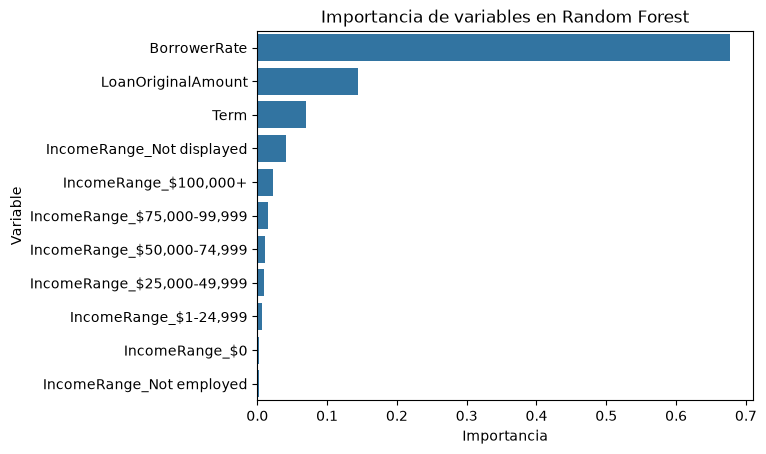

In [ ]:
##Importancia de variables en Random Forest
# Obtener nombres de columnas después de la transformación
ohe = grid_rf.best_estimator_.named_steps['preprocessor'].named_transformers_['cat']
encoded_cols = ohe.get_feature_names_out(['IncomeRange'])

# Combinar con las columnas numéricas
num_cols = ['BorrowerRate', 'LoanOriginalAmount', 'Term']
features = list(num_cols) + list(encoded_cols)

# Emparejar con importancias
importances = grid_rf.best_estimator_.named_steps['model'].feature_importances_

feat_importances = pd.DataFrame({
    "Variable": features,
    "Importancia": importances
}).sort_values(by="Importancia", ascending=False)

# Graficar
sns.barplot(x="Importancia", y="Variable", data=feat_importances)
plt.title("Importancia de variables en Random Forest")
plt.show()
